=== RAW INPUT: ===


,,Line Item,Description,Projected Budget,Projected Commitments,Estimate at Completion,Actuals To Date,Actuals + Projections,Unnamed: 8,Unnamed: 9,...,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61
0,NaN,0,Site Clearance of Hazardous or Obstructing Exi...,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,0.001,Environmental Site Conditions,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,,0.002,"Removal and Disposal of Haz Mat (e,g, Asbestos...",0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,,0.003,Relocation or Replacement of Existing Facilities,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,,0.004,Demolition of Existing Facilities,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,,7.709,"Meals, Travel & Entertainment Costs",272.75,272.75,272.75,272.75,272.75,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,,7.799,"Other Surveys, Testing, or Reproduction Costs",0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,NaN,8,Special Cost Items,"188,761.00","184,084.00","188,761.00","184,084.00","184,084.00",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,,8.801,Loan Finance Charges/lnterest During Construction,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== PREDICTIONS: ===
Duration:  [56.38203037]
Max Value:  [3932054.42710441]
Growth Rate:  [0.28465688]
Midpoint:  [40.62190217]


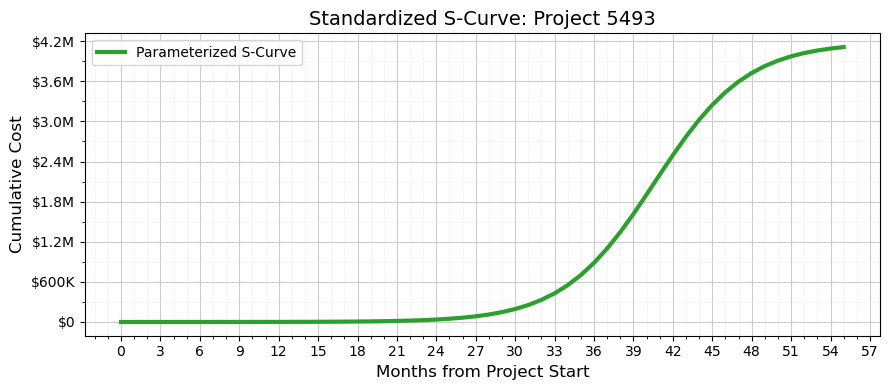

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

#########################################
""""

Setup - will be replaced once integrated with the front end
Will be using project 5493 bc I like the graphs

I removed the timeline from project 5493 so you can see how the curve is
predicted from just the base features: Gross Sq Footage, Projected Budget,
Projected Commitments, and Estimate at Completion

"""

# import project 5493
filepath = "5493.csv"
project_code = Path(filepath).stem
df = pd.read_csv(filepath)

print("=== RAW INPUT: ===")
display(df.head(100))

# assign gross sq footage
gross_sq = 4000

#########################################

# Some formatting/ cleaning up stuff
df_cleaned = df.iloc[:, 1:].copy()
if len(df_cleaned) > 0:
    df_cleaned.iat[-1, 0] = "Total"
    start_col_idx = 6
    if df_cleaned.shape[1] > start_col_idx:
        last_row = df_cleaned.iloc[[-1], start_col_idx:]
        cleaned_last_row = (
            last_row.astype("string")
            .apply(lambda s: s.str.split(r"\r\n|\n|\r", regex=True).str[0])
        )
        df_cleaned.iloc[-1, start_col_idx:] = cleaned_last_row.iloc[0].to_numpy()
df_cleaned = df_cleaned.reset_index(drop=True)
df = df_cleaned

# Keep only totals
total_only = df[df.iloc[:, 0].astype(str).eq("Total")].copy()
total_only = total_only.drop(columns=["Line Item", "Description"])
df = total_only.reset_index(drop=True)

# Add project code
df.insert(0, "Project Code", project_code)

# Add gross sq footage
df.insert(1, "Gross Sq Footage", gross_sq)

# Remove "Actuals" columns
cols_to_drop = ["Actuals To Date", "Actuals + Projections"]
df = df.drop(columns=cols_to_drop, errors="ignore")

# Convert feature values to float
df[['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion']] = (
df[['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion']]
.replace({'[\$,]': ''}, regex=True)
.astype(float)
)

# Add new features EAC Budget Ratio and Commitments Budget Ratio (financial health independent of project size)
df['EAC_Budget_Ratio'] = (df['Estimate at Completion'] / df['Projected Budget'].replace(0, np.nan))
df['Commitments_Budget_Ratio'] = (df['Projected Commitments'] / df['Projected Budget'].replace(0, np.nan))

#########################################
""""

IMPORTING THE MODELS

"""
#########################################

import joblib

# Duration
duration_model_path = Path("trained_models/Duration_Months_model_v2.joblib")
duration_model = joblib.load(duration_model_path)

# S_Curve_L
L_model_path = Path("trained_models/S_Curve_L_model_v2.joblib")
L_model = joblib.load(L_model_path)

# S_Curve_k
k_model_path = Path("trained_models/S_Curve_k_model_v2.joblib")
k_model = joblib.load(k_model_path)

# S_Curve_t0
t0_model_path = Path("trained_models/S_Curve_t0_model_v2.joblib")
t0_model = joblib.load(t0_model_path)

feature_cols = [
    'Gross Sq Footage', 'Projected Budget', 'Projected Commitments',
    'Estimate at Completion', 'EAC_Budget_Ratio', 'Commitments_Budget_Ratio'
]

print("=== PREDICTIONS: ===")

# Predict with models
duration_prediction = duration_model.predict(df[feature_cols])
print("Duration: ", duration_prediction)
L_prediction = L_model.predict(df[feature_cols])
print("Max Value: ", L_prediction)
k_prediction = k_model.predict(df[feature_cols])
print("Growth Rate: ", k_prediction)
t0_prediction = t0_model.predict(df[feature_cols])
print("Midpoint: ", t0_prediction)

# Build predictions DataFrame
predictions_df = pd.DataFrame({
    "Project Code": df['Project Code'].values,
    "Duration_Months": duration_prediction, "S_Curve_L": L_prediction, "S_Curve_k": k_prediction, "S_Curve_t0": t0_prediction
    })

# Replace "S_Curve_L" predictions with "Projected Commitments" data
predictions_df["S_Curve_L"] = df["Projected Commitments"]

from matplotlib.ticker import MultipleLocator, FuncFormatter

def logistic_curve(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

### DISPLAY THE CURVE
def format_currency(x, pos):
    if x >= 1e6:
        return f'${x * 1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x * 1e-3:.0f}K'
    else:
        return f'${x:,.0f}'

row = predictions_df.iloc[0]
L = row['S_Curve_L']
k = row['S_Curve_k']
t0 = row['S_Curve_t0']
duration = row['Duration_Months']

# Generate X axis and calculate Y values
x_data = np.arange(int(duration))
predicted_y = logistic_curve(x_data, L, k, t0)

# Plot the curve
plt.figure(figsize=(9, 4))
plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
plt.title(f"Standardized S-Curve: Project {row['Project Code']}", fontsize=14)
plt.xlabel("Months from Project Start", fontsize=12) 
plt.ylabel("Cumulative Cost", fontsize=12) 
ax = plt.gca() 

# Formatting the graph
ax.xaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_formatter(FuncFormatter(format_currency))
ax.yaxis.set_major_locator(plt.MaxNLocator(8)) 
ax.yaxis.set_minor_locator(plt.MaxNLocator(16)) 
plt.grid(which='major', color='#CCCCCC', linestyle='-', linewidth=0.8)
plt.grid(which='minor', color='#EEEEEE', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()